In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score


# 1. Main model (TF-IDF + linguistic features)

## Load Feature Dataset

In [114]:
X = pd.read_csv("features_matrix.csv")
target = pd.read_csv("target_variable.csv")

df = pd.concat([X, target], axis=1)

In [115]:
X.shape

(790, 2235)

## Create target variable

In [104]:
# Calculate average duration in top 50
avg_duration= df["days_in_top50"].mean()
print(avg_duration)

# Calculate median duration in top 50
median_duration = df["days_in_top50"].median()
print(median_duration)

58.50379746835443
8.0


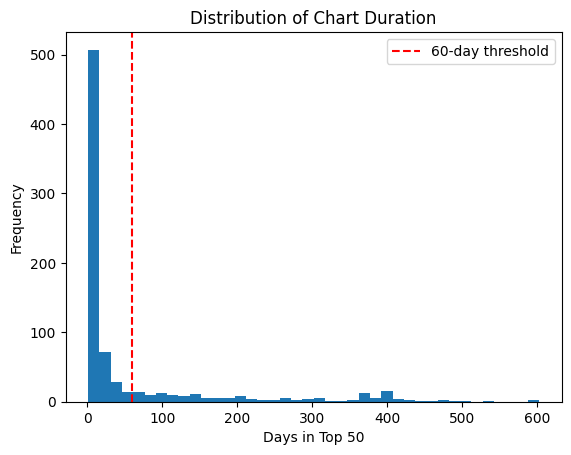

In [105]:
plt.hist(df["days_in_top50"], bins=40)

plt.axvline(60, color="red", linestyle="--", label="60-day threshold")

plt.title("Distribution of Chart Duration")
plt.xlabel("Days in Top 50")
plt.ylabel("Frequency")
plt.legend()

plt.show()


In [106]:
# Create binary target variable using a 60-day threshold

threshold = 60

df = df.copy()

df["long_chart"] = (df["days_in_top50"] > threshold).astype(int)

y = df["long_chart"]
X = df.drop(columns=["days_in_top50", "long_chart"])

print(y.value_counts(normalize=True))


long_chart
0    0.786076
1    0.213924
Name: proportion, dtype: float64


We define a binary target where songs above 60 days are considered long-lasting.

In [107]:
# Sanity check: check for extremely rare tf-idf features that may cause issues in modeling
# count how many songs contain each feature
feature_occurrence = (X > 0).sum(axis=0)

rare_features = (feature_occurrence <= 5).sum()

print("Number of features appearing in ≤5 songs:", rare_features)
print("Total features:", X.shape[1])

Number of features appearing in ≤5 songs: 0
Total features: 2235


In [108]:
# Sanity check: ensure X and y have the same number of samples and aligned indices
print(X.shape[0], y.shape[0])
print(X.index.equals(y.index))

790 790
True


## Train and test split

In [ ]:
# Split data into train and test sets with stratification to maintain class balance

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (632, 2235)
Test shape: (158, 2235)


## Logistic Regression Model

In [ ]:
# Initialize logistic regression model with increased max_iter to ensure convergence

for c in [0.5, 1, 5, 10]:
    model = LogisticRegression(
        solver="liblinear",
        max_iter=5000,
        C=c,
        class_weight="balanced"
    )

print("C =", c)

C = 10


## 5-fold cross-validation

In [ ]:
# Perform 5-fold cross-validation and evaluate multiple metrics

scoring = ["accuracy", "precision", "recall", "roc_auc"]

cv_results = cross_validate(
    model,
    X_train,
    y_train,
    cv=5,
    scoring=scoring
)

for metric in scoring:
    print(metric, ":", cv_results[f"test_{metric}"].mean())

accuracy : 0.7389451318585177
precision : 0.38228054298642533
recall : 0.2962962962962963
roc_auc : 0.6009775533108866


In [ ]:
# Train final model on full training set
model.fit(X_train, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",10
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term

## Evaluate on test set

In [ ]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("Test Accuracy:", accuracy)
print("Test Precision:", precision)
print("Test Recall:", recall)
print("Test ROC-AUC:", auc)

Test Accuracy: 0.6392405063291139
Test Precision: 0.1891891891891892
Test Recall: 0.20588235294117646
Test ROC-AUC: 0.5374762808349146


# 2. Feature importance analysis

## TF-IDF

In [ ]:
feature_names = X.columns

coef = pd.Series(model.coef_[0], index=feature_names)

# linguistic features
ling_features = [
    "ttr",
    "avg_word_length",
    "repetition_ratio",
    "max_word_freq",
    "sentiment_polarity"
]

# keep only TF-IDF word features
tfidf_columns = [c for c in X.columns if c not in ling_features]

coef_words = coef[tfidf_columns]

# Remove repeated-word bigrams (e.g., "go go", "one one")
coef_words = coef_words[~coef_words.index.str.match(r'^(\w+)\s+\1$')]

Top predictors of LONG chart duration:
wasted       3.170394
waiting      3.157593
show         3.153630
whatever     2.954046
hate         2.950284
night        2.907983
christmas    2.905928
type         2.897079
showed       2.830811
goodbye      2.806301
make         2.779801
tree         2.733122
hold         2.682964
taste        2.671536
minute       2.611476
mouth        2.594571
sick         2.590315
monster      2.533994
fast         2.533640
pink         2.530713
dtype: float64


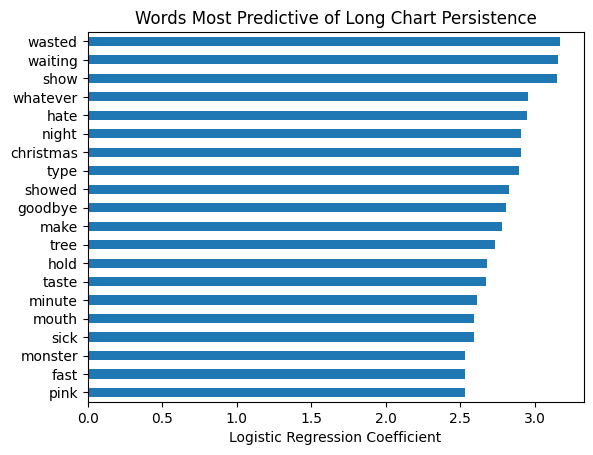

In [ ]:
# Words predicting long chart duration

top_positive = coef_words.sort_values(ascending=False).head(20)

print("Top predictors of LONG chart duration:")
print(top_positive)

# Visualize top positive predictors
top_positive.sort_values().plot(kind="barh")

plt.title("Words Most Predictive of Long Chart Persistence")
plt.xlabel("Logistic Regression Coefficient")

plt.show()

Words such as "hate", “kiss”, “hold”, “mind”, and “one” are positively associated with longer chart persistence, suggesting that songs with emotionally expressive or relational vocabulary may remain longer in the charts.
Words as "christmas" and "mistletoe" reflect holiday songs, which often stay in charts for long seasonal periods

Top predictors of SHORT chart duration:
fuckin        -2.642615
gon           -2.618354
sayin         -2.318126
born          -2.263993
fire          -2.234662
best          -2.204264
hope          -2.155936
love          -2.138980
time          -2.083142
gave          -2.071385
first         -2.055722
top           -2.047971
tell em       -1.931098
new           -1.912069
tryna         -1.907454
talk          -1.854266
santa claus   -1.845854
claus         -1.845854
play          -1.826373
bye           -1.816210
dtype: float64


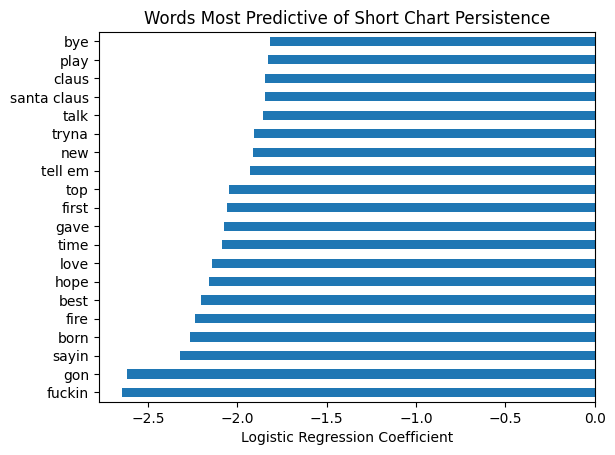

In [ ]:
# Words predicting short chart duration

top_negative = coef_words.sort_values().head(20)

print("Top predictors of SHORT chart duration:")
print(top_negative)

# Visualize top negative predictors
top_negative.sort_values().plot(kind="barh")

plt.title("Words Most Predictive of Short Chart Persistence")
plt.xlabel("Logistic Regression Coefficient")

plt.show()


Words such as “wish”, “ride”, “dance”, and “diamond” are negatively associated with chart persistence, suggesting that some lexical patterns may be more common in songs with shorter chart lifetimes.

## Linguistic features

In [ ]:
linguistic_coef = coef[[
    "ttr",
    "avg_word_length",
    "repetition_ratio",
    "max_word_freq",
    "sentiment_polarity"
]]

print(linguistic_coef)


ttr                  -0.339247
avg_word_length      -0.087599
repetition_ratio      0.440332
max_word_freq        -0.285682
sentiment_polarity   -0.104645
dtype: float64


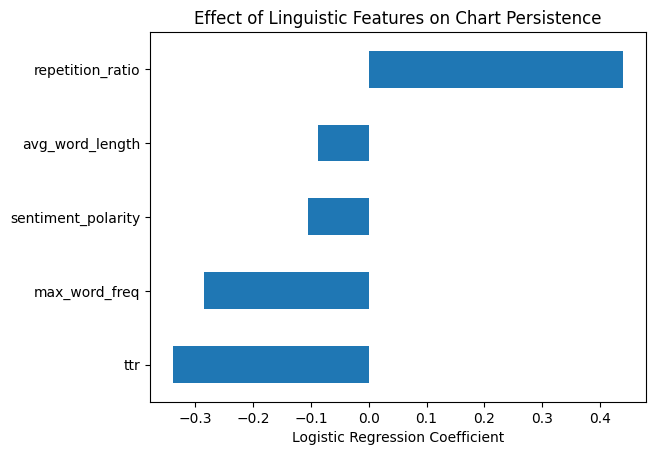

In [ ]:
plt.figure()

linguistic_coef.sort_values().plot(kind="barh")

plt.title("Effect of Linguistic Features on Chart Persistence")
plt.xlabel("Logistic Regression Coefficient")

plt.show()


The model suggests that repetition-related features increase chart persistence, while higher lexical diversity decreases it. This supports the idea that simpler, more repetitive and lexically simple lyrics tend to remain longer in the charts.

# 3. Feature Group Model Comparison

In [ ]:
# Define linguistic features to analyze
linguistic_cols = [
    "ttr",
    "avg_word_length",
    "repetition_ratio",
    "max_word_freq",
    "sentiment_polarity"
]

# Split features into linguistic and tf-idf sets
X_linguistic = X[linguistic_cols]

X_tfidf = X.drop(columns=linguistic_cols)

X_combined = X

# Train/test split
X_train_comb, X_test_comb, y_train, y_test = train_test_split(
    X_combined,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

X_train_ling = X_train_comb[linguistic_cols]
X_test_ling = X_test_comb[linguistic_cols]

X_train_tfidf = X_train_comb.drop(columns=linguistic_cols)
X_test_tfidf = X_test_comb.drop(columns=linguistic_cols)

# Define logistic regression model
model = LogisticRegression(
    solver="liblinear",
    max_iter=5000,
    C=10
)

# Train and evaluate on linguistic features only
model.fit(X_train_ling, y_train)
y_prob_ling = model.predict_proba(X_test_ling)[:,1]
auc_ling = roc_auc_score(y_test, y_prob_ling)
print("Linguistic Features ROC-AUC:", auc_ling)

# Train and evaluate on tf-idf features only
model.fit(X_train_tfidf, y_train)
y_prob_tfidf = model.predict_proba(X_test_tfidf)[:,1]
auc_tfidf = roc_auc_score(y_test, y_prob_tfidf)
print("TF-IDF Features ROC-AUC:", auc_tfidf)

# Train and evaluate on combined features
model.fit(X_train_comb, y_train)
y_prob_comb = model.predict_proba(X_test_comb)[:,1]
auc_comb = roc_auc_score(y_test, y_prob_comb)
print("Combined Model ROC-AUC:", auc_comb)



Linguistic Features ROC-AUC: 0.5037950664136622
TF-IDF Features ROC-AUC: 0.5415085388994307
Combined Model ROC-AUC: 0.543168880455408


The TF-IDF model slightly outperforms the linguistic feature model, suggesting that specific lexical content carries more predictive information than structural characteristics of lyrics. However, the combined model achieves the highest ROC-AUC, indicating that both lexical and structural features contribute to predicting chart persistence.

# 4. Main model + audio controls

In [ ]:
songs_df = pd.read_csv("data/final_df.csv")

# Load audio features from the original dataset

audio_cols = [
    "danceability",
    "energy",
    "valence",
    "tempo",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness"
]

# Extract audio features from the SAME dataframe used to build X
X_audio = songs_df[audio_cols]

# Reset indices so rows align
X_audio = X_audio.iloc[:len(X)]

X_audio = X_audio.reset_index(drop=True)
X = X.reset_index(drop=True)

# Combine lyrics + audio
X_lyrics_audio = pd.concat([X, X_audio], axis=1)

print(X_lyrics_audio.shape)
print(y.shape)


# Train/test split for combined lyrics + audio features
X_train_la, X_test_la, y_train_la, y_test_la = train_test_split(
    X_lyrics_audio,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


# Train and evaluate model on combined lyrics + audio features
model_la = LogisticRegression(
    solver="liblinear",
    max_iter=5000,
    C=10
)

model_la.fit(X_train_la, y_train_la)

y_prob_la = model_la.predict_proba(X_test_la)[:,1]

auc_la = roc_auc_score(y_test_la, y_prob_la)

print("Lyrics + Audio Model ROC-AUC:", auc_la)




(790, 2243)
(790,)
Lyrics + Audio Model ROC-AUC: 0.49786527514231493


In [ ]:
print(X_lyrics_audio.columns)


Index(['ttr', 'avg_word_length', 'repetition_ratio', 'max_word_freq',
       'sentiment_polarity', 'abandoned', 'account', 'ace', 'across', 'act',
       ...
       'zero', 'zone', 'danceability', 'energy', 'valence', 'tempo',
       'loudness', 'speechiness', 'acousticness', 'instrumentalness'],
      dtype='str', length=2243)


# 5. Models comparison

In [ ]:
results = pd.DataFrame({
    "Model": [
        "Linguistic Features",
        "TF-IDF Words",
        "Combined Lyrics Model",
        "Lyrics + Audio Model"
    ],
    "ROC-AUC": [
        auc_ling,
        auc_tfidf,
        auc_comb,
        auc_la
    ]
})

print(results)


                   Model   ROC-AUC
0    Linguistic Features  0.503795
1           TF-IDF Words  0.541509
2  Combined Lyrics Model  0.543169
3   Lyrics + Audio Model  0.497865


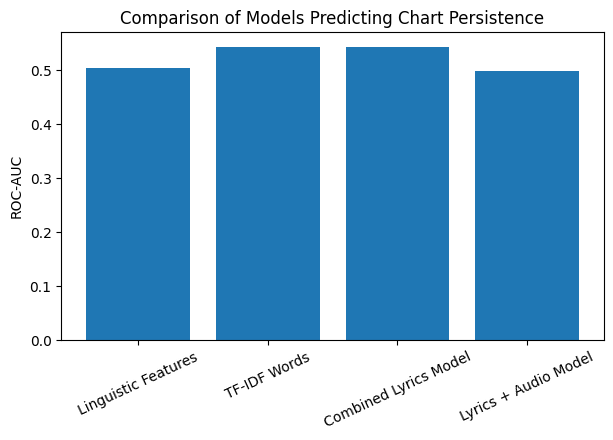

In [ ]:
plt.figure(figsize=(7,4))

plt.bar(results["Model"], results["ROC-AUC"])

plt.title("Comparison of Models Predicting Chart Persistence")
plt.ylabel("ROC-AUC")

plt.xticks(rotation=25)

plt.show()


In [ ]:
results.sort_values("ROC-AUC", ascending=False)


,Model,ROC-AUC
2,Combined Lyrics Model,0.543169
1,TF-IDF Words,0.541509
0,Linguistic Features,0.503795
3,Lyrics + Audio Model,0.497865


The TF-IDF representation performs better than the linguistic feature model, suggesting that specific words used in the lyrics carry more predictive information than general linguistic properties such as vocabulary diversity or repetition. The combined lyrics model achieves the highest ROC-AUC, although the improvement over the TF-IDF model is small. Adding Spotify audio features does not significantly improve predictive performance, indicating that lyrical content captures most of the detectable signal related to chart persistence in this dataset.

# Next Steps:
1. Preprocessing - take out the duplicated songs first - Maria + Move it ✅
2. Change the threshold to 60 ~ Mean - Yaz ✅
3. Correlation of linguistic itens with persistence (feature engineering) - Yaz ✅
4. Don't drop artist name preprocessing - Yaz ✅
5. NEW model with LDA topics in the Model - Manzi
6. Change the Topics Names - Manzi 
7. Drop Like (unigram) from the bag of words - YAZ ✅
8. Lower a bit max_df in count_vectorize - Yaz ✅


